In [19]:
import tensorflow as tf


In [20]:
!pip install tensorflow-datasets

import tensorflow_datasets as tfds
print(tfds.__version__)


4.9.9


# IMDB Dataset

In [21]:
train_data = tfds.as_numpy(tfds.load('imdb_reviews', split='train'))


In [22]:
train_data


In [23]:
imdb_sentences = []
imdb_labels = []

for item in train_data:
  # print(item)
  # break
  imdb_sentences.append(str(item['text']))
  imdb_labels.append(item['label'])


In [24]:
len(imdb_sentences)


25000

In [25]:
len(imdb_labels), imdb_labels


(25000,
 [np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  np.int64(0),
  np.int64(1),
  np.int64(1),
  np.int64(1),
  

In [26]:
imdb_sentences[25]


'b"Well, i rented this movie and found out it realllllllly sucks. It is about that family with the stepmother and the same stupid fights in the family,then the cool son comes with his stupid camera and he likes to take a photo to damaged building and weird things and weird movie ,and then he asks his father to take him to a side trip and simply agrees, etc etc etc..... They go to that town which no one know it exists (blah blah blah) And the most annoying thing is that the movie ends and yet you don\'t understand what is THAT MOVIE!!!!I have seen many mystery movies but that was the worst, Honestly it doesn\'t have a description at all and i wish i didn\'t see it."'

In [27]:
imdb_labels[25]


np.int64(0)

In [28]:
training_sentences = imdb_sentences[:20000]
test_sentences = imdb_sentences[20000:]

training_labels = imdb_labels[:20000]
test_labels = imdb_labels[20000:]


In [29]:
len(training_sentences), len(test_sentences)


(20000, 5000)

# Tokenisation (Phrases --> Liste de Mots

In [30]:
phrase = "Je suis au marché"


In [31]:
phrase.split(" ")


['Je', 'suis', 'au', 'marché']

In [32]:
phrases = ["Je suis au marché", "Je travaille au marché"]


In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer


In [34]:
tokenizer = Tokenizer()


In [35]:
tokenizer.fit_on_texts(phrases)


In [36]:
tokenizer.word_index


{'je': 1, 'au': 2, 'marché': 3, 'suis': 4, 'travaille': 5}

In [37]:
tokenizer.index_word


{1: 'je', 2: 'au', 3: 'marché', 4: 'suis', 5: 'travaille'}

In [38]:
tokenizer.texts_to_sequences(phrases)


[[1, 4, 2, 3], [1, 5, 2, 3]]

In [39]:
test = ['Je vends au Marché']


In [40]:
tokenizer.texts_to_sequences(test) # je au marché


[[1, 2, 3]]

In [41]:
test = ['Hello, viens']


In [42]:
tokenizer.texts_to_sequences(test)


[[]]

In [43]:
tokenizer = Tokenizer(num_words=100, oov_token="<OOV>")
tokenizer.fit_on_texts(phrases)


In [44]:
tokenizer.word_index


{'<OOV>': 1, 'je': 2, 'au': 3, 'marché': 4, 'suis': 5, 'travaille': 6}

In [45]:
test = ['Je vends au Marché']
tokenizer.texts_to_sequences(test)


[[2, 1, 3, 4]]

# Padding

In [46]:
phrases = ["Je suis au marché",
           "Je travaille au marché",
           "es-tu rentré du marché?",
           "Je nettoie le marché tous les jours avant de commencer à vendre le matin"]


tokenizer = Tokenizer(num_words = 100, oov_token="<OOV>")
tokenizer.fit_on_texts(phrases)
word_index = tokenizer.word_index
sequences = tokenizer.texts_to_sequences(phrases)


In [47]:
sequences


[[3, 6, 4, 2],
 [3, 7, 4, 2],
 [8, 9, 10, 11, 2],
 [3, 12, 5, 2, 13, 14, 15, 16, 17, 18, 19, 20, 5, 21]]

In [48]:
word_index


{'<OOV>': 1,
 'marché': 2,
 'je': 3,
 'au': 4,
 'le': 5,
 'suis': 6,
 'travaille': 7,
 'es': 8,
 'tu': 9,
 'rentré': 10,
 'du': 11,
 'nettoie': 12,
 'tous': 13,
 'les': 14,
 'jours': 15,
 'avant': 16,
 'de': 17,
 'commencer': 18,
 'à': 19,
 'vendre': 20,
 'matin': 21}

In [49]:
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [50]:
sequences


[[3, 6, 4, 2],
 [3, 7, 4, 2],
 [8, 9, 10, 11, 2],
 [3, 12, 5, 2, 13, 14, 15, 16, 17, 18, 19, 20, 5, 21]]

In [51]:
pad_sequences(sequences)


array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  6,  4,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  3,  7,  4,  2],
       [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  8,  9, 10, 11,  2],
       [ 3, 12,  5,  2, 13, 14, 15, 16, 17, 18, 19, 20,  5, 21]],
      dtype=int32)

In [52]:
pad_sequences(sequences, padding="post")


array([[ 3,  6,  4,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3,  7,  4,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 8,  9, 10, 11,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 3, 12,  5,  2, 13, 14, 15, 16, 17, 18, 19, 20,  5, 21]],
      dtype=int32)

In [53]:
pad_sequences(sequences, padding="post", maxlen=7)


array([[ 3,  6,  4,  2,  0,  0,  0],
       [ 3,  7,  4,  2,  0,  0,  0],
       [ 8,  9, 10, 11,  2,  0,  0],
       [16, 17, 18, 19, 20,  5, 21]], dtype=int32)

In [54]:
pad_sequences(sequences, padding="post", maxlen=7, truncating="post")


array([[ 3,  6,  4,  2,  0,  0,  0],
       [ 3,  7,  4,  2,  0,  0,  0],
       [ 8,  9, 10, 11,  2,  0,  0],
       [ 3, 12,  5,  2, 13, 14, 15]], dtype=int32)

# Stop words

In [55]:
phrase = "Je vais au marché le Jeudi"


In [56]:
stopwords = ['au', "le"]


In [57]:
words = phrase.split(' ')
phrase_nettoyee = []

for word in words:
  if word not in stopwords:
    phrase_nettoyee.append(word)


In [58]:
phrase_nettoyee


['Je', 'vais', 'marché', 'Jeudi']

In [59]:
" ".join(phrase_nettoyee)


'Je vais marché Jeudi'

# Approche de calcul du Sentiment

In [60]:
phrase = "Votre connexion est lente"


In [61]:
{5 : 0}


{5: 0}

In [62]:
phrase = "Votre connexion est agréablement lente"


In [63]:
{"Votre": [1, 0, 5],
 "connexion": [0, 1, 9],
 "est": [3, 2, 3],
 "agréablement": [2, 3, 12],
 "lente": [5, 4, 5]}


{'Votre': [1, 0, 5],
 'connexion': [0, 1, 9],
 'est': [3, 2, 3],
 'agréablement': [2, 3, 12],
 'lente': [5, 4, 5]}

# Embedding (plongement)

In [64]:
training_sentences[42]


'b\'One of the weaker Carry On adventures sees Sid James as the head of a crime gang stealing contraceptive pills. The fourth of the series to be hospital-based, it\\\'s possibly the least of the genre. There\\\'s a curiously flat feel throughout, with all seemingly squandered on below-par material. This is far from the late-70s nadir, but Williams, James, Bresslaw, Maynard et al. are all class performers yet not given the backing of a script equal to their ability.<br /><br />Most of the gags are onrunning, rather than episodic as Carry Ons usually are. So that instead of the traditional hit and miss ratio, if you don\\\'t find the joke funny in the first place you\\\'re stuck with it for most of the film. These continuous plot strands include Williams \\xc2\\x96 for no good reason \\xc2\\x96 worrying that he\\\'s changing sex, and Kenneth Cope in drag. Like the stagy physical pratt falls, the whole thing feels more contrived than in other movies, and lacking in cast interest. Continu

In [65]:
training_labels[42]


np.int64(0)

In [66]:
# vocab_size, embedding_dim (78371)


In [67]:
tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")


In [68]:
training_padded[42]


array([4668,    5,    2, 5838, 1706,   22, 2438, 1117, 5099,  594,   15,
          2,  423,    5,    4], dtype=int32)

In [69]:
import numpy as np

training_labels = np.array(training_labels)
test_labels = np.array(test_labels)


In [70]:
model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(20000, 20),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)


In [71]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [72]:
20*8 + 8


168

In [73]:
model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])


In [74]:
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)


In [75]:
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp])


Epoch 1/50
621/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5859 - loss: 0.6721

625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.6382 - loss: 0.6391 - val_accuracy: 0.6922 - val_loss: 0.5860
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7585 - loss: 0.5055

625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7578 - loss: 0.5010 - val_accuracy: 0.6996 - val_loss: 0.5806
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8120 - loss: 0.4212 - val_accuracy: 0.6940 - val_loss: 0.6120
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8395 - loss: 0.3707 - val_accuracy: 0.6882 - val_loss: 0.6540
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8580 - loss: 0.3358 - val_accuracy: 0.6896 - val_loss: 0.7006
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8722 - loss: 0.3077 - val_accuracy: 0.6818 - val_loss: 0.7456
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8824 - loss: 0.2875 - val_accuracy: 0.6828 - val_loss: 0.7880
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8885 - loss: 0.2705 - val_accuracy: 0.6734 - val_loss: 0.8365
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8939 - loss: 0.2557 - val_accuracy: 0.6

In [76]:
import matplotlib.pyplot as plt


def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.show()


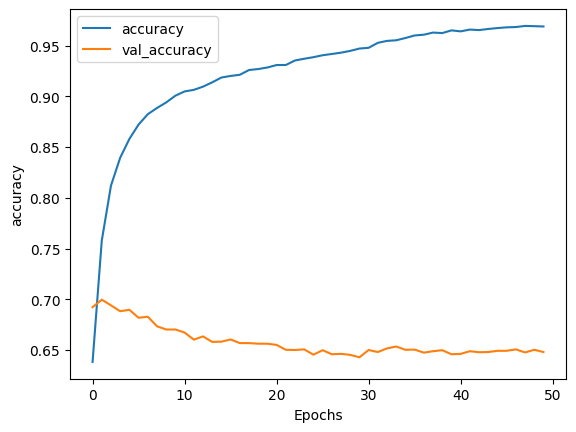

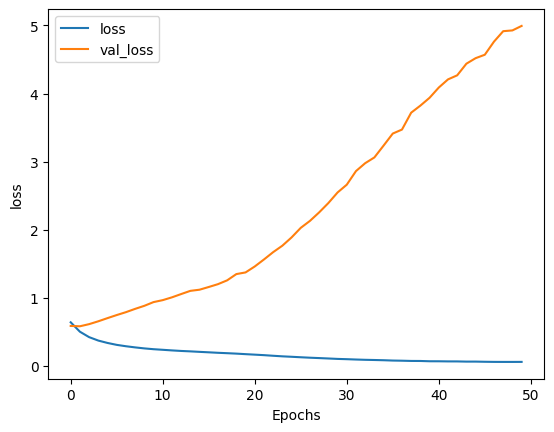

In [77]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")


# Vocab size

In [78]:
# 20000

vocab_size = 1

vocab_size = 78371


In [79]:
len(word_index)


78371

In [80]:
(78371* 20)


1567420

In [81]:
wc = tokenizer.word_counts


In [82]:
wc = sorted(wc.items(), key=lambda t:t[1], reverse=True)


In [83]:
import pandas as pd


In [84]:
df = pd.DataFrame(wc, columns=['mots', "frequence"])


In [85]:
df[df['frequence'] > 10]


,mots,frequence
0,the,268774
1,and,131448
2,a,130000
3,of,116684
4,to,108554
...,...,...
17156,crockett,11
17157,liliom,11
17158,nikhil,11
17159,hanka,11


In [86]:
test_tok = Tokenizer()
test_tok.fit_on_texts(test_sentences)


In [87]:
test_tok.word_index


{'the': 1,
 'a': 2,
 'and': 3,
 'of': 4,
 'to': 5,
 'is': 6,
 'br': 7,
 'in': 8,
 'it': 9,
 'i': 10,
 'this': 11,
 'that': 12,
 'was': 13,
 'as': 14,
 'with': 15,
 'for': 16,
 'movie': 17,
 'but': 18,
 'film': 19,
 "'s": 20,
 'on': 21,
 'you': 22,
 'not': 23,
 'he': 24,
 'are': 25,
 'his': 26,
 'have': 27,
 'be': 28,
 'one': 29,
 'all': 30,
 'by': 31,
 'at': 32,
 'an': 33,
 'they': 34,
 'who': 35,
 'from': 36,
 'so': 37,
 'like': 38,
 'her': 39,
 'just': 40,
 'or': 41,
 "'t": 42,
 'about': 43,
 'has': 44,
 'out': 45,
 'there': 46,
 "'": 47,
 'if': 48,
 'some': 49,
 'good': 50,
 'what': 51,
 'more': 52,
 'when': 53,
 'very': 54,
 'she': 55,
 'up': 56,
 'b': 57,
 'no': 58,
 'even': 59,
 'can': 60,
 'time': 61,
 'my': 62,
 'which': 63,
 'only': 64,
 'story': 65,
 'would': 66,
 'really': 67,
 'see': 68,
 'their': 69,
 'had': 70,
 'were': 71,
 'well': 72,
 'me': 73,
 'we': 74,
 'than': 75,
 'much': 76,
 'get': 77,
 'bad': 78,
 'because': 79,
 'great': 80,
 'other': 81,
 'into': 82,
 'will':

In [88]:
test_words = test_tok.word_index.keys()


In [89]:
test_words


dict_keys(['the', 'a', 'and', 'of', 'to', 'is', 'br', 'in', 'it', 'i', 'this', 'that', 'was', 'as', 'with', 'for', 'movie', 'but', 'film', "'s", 'on', 'you', 'not', 'he', 'are', 'his', 'have', 'be', 'one', 'all', 'by', 'at', 'an', 'they', 'who', 'from', 'so', 'like', 'her', 'just', 'or', "'t", 'about', 'has', 'out', 'there', "'", 'if', 'some', 'good', 'what', 'more', 'when', 'very', 'she', 'up', 'b', 'no', 'even', 'can', 'time', 'my', 'which', 'only', 'story', 'would', 'really', 'see', 'their', 'had', 'were', 'well', 'me', 'we', 'than', 'much', 'get', 'bad', 'because', 'great', 'other', 'into', 'will', 'been', 'people', 'first', 'also', 'most', 'him', 'how', 'do', 'made', 'them', 'way', 'then', 'too', 'could', 'its', "it's", 'make', 'any', 'movies', 'after', 'think', 'films', 'characters', 'watch', 'seen', 'life', 'many', 'character', 'two', 'little', 'know', 'acting', 'best', 'plot', 'where', 'show', 'being', 'off', 'did', 'over', 'never', 'does', 'love', 'ever', 'man', 'here', 'bette

In [90]:
train_words = df['mots'].tolist()


In [91]:
len(train_words), len(test_words)


(78370, 42047)

In [92]:
inter = set(train_words).intersection(test_words)


In [93]:
len(inter)


33879

In [94]:
vocab_size = 29000

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, 20),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp])


Epoch 1/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5946 - loss: 0.6746

625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.6445 - loss: 0.6448 - val_accuracy: 0.6848 - val_loss: 0.5915
Epoch 2/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7628 - loss: 0.5144

625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.7617 - loss: 0.5062 - val_accuracy: 0.7048 - val_loss: 0.5757
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8138 - loss: 0.4202 - val_accuracy: 0.6976 - val_loss: 0.6059
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - accuracy: 0.8479 - loss: 0.3620 - val_accuracy: 0.6918 - val_loss: 0.6473
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - accuracy: 0.8647 - loss: 0.3218 - val_accuracy: 0.6886 - val_loss: 0.7007
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.8813 - loss: 0.2903 - val_accuracy: 0.6846 - val_loss: 0.7464
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8934 - loss: 0.2657 - val_accuracy: 0.6768 - val_loss: 0.8177
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.9010 - loss: 0.2476 - val_accuracy: 0.6772 - val_loss: 0.8592
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 17ms/step - accuracy: 0.9068 - loss: 0.2319 - val_accurac

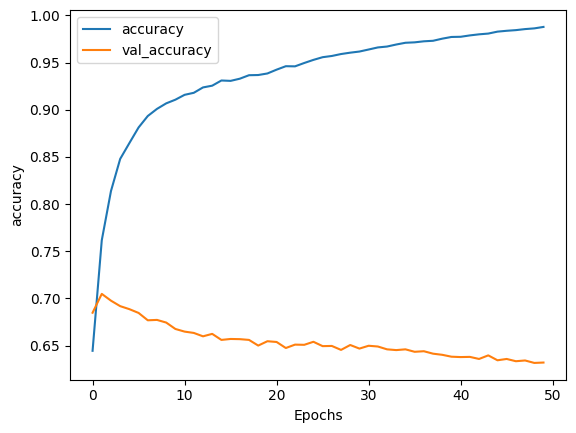

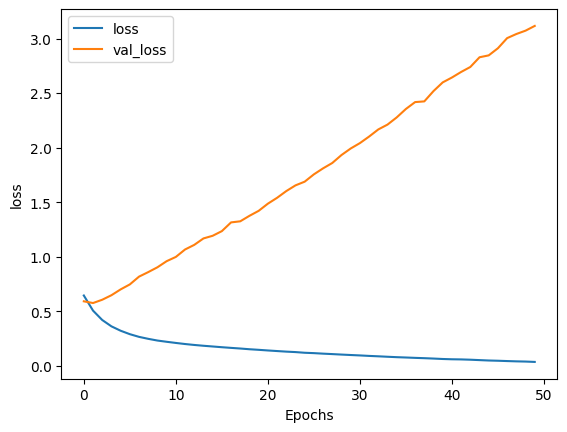

In [95]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")


# Embedding dim

In [96]:
np.power(vocab_size, 1/4)


np.float64(13.049669101523763)

In [97]:
vocab_size = 29000
embedding_dim=13

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(8, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp])


Epoch 1/50
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5735 - loss: 0.6818

625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.6244 - loss: 0.6586 - val_accuracy: 0.6800 - val_loss: 0.6055
Epoch 2/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7457 - loss: 0.5350

625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7511 - loss: 0.5216 - val_accuracy: 0.6998 - val_loss: 0.5766
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8050 - loss: 0.4328 - val_accuracy: 0.6984 - val_loss: 0.5998
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.8374 - loss: 0.3744 - val_accuracy: 0.6942 - val_loss: 0.6315
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8599 - loss: 0.3328 - val_accuracy: 0.6904 - val_loss: 0.6757
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8756 - loss: 0.3003 - val_accuracy: 0.6878 - val_loss: 0.7311
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8851 - loss: 0.2765 - val_accuracy: 0.6788 - val_loss: 0.7686
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.8974 - loss: 0.2556 - val_accuracy: 0.6778 - val_loss: 0.8203
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9020 - loss: 0.2395 - val_accuracy: 0.6

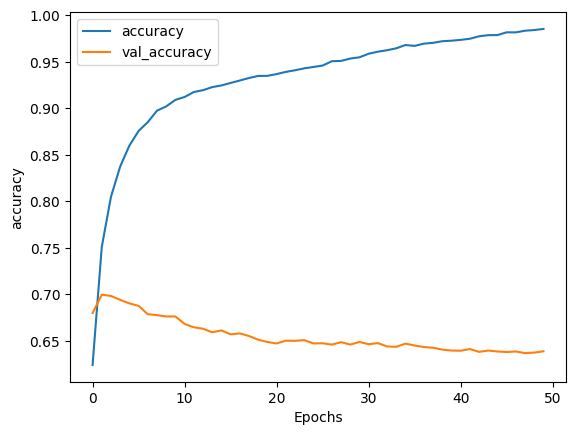

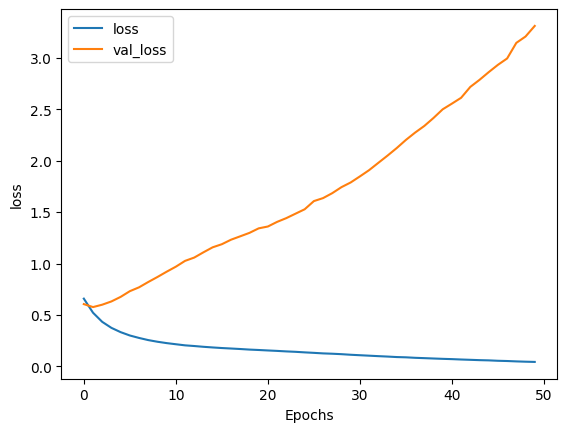

In [98]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")


# Architecture du model

In [99]:
vocab_size = 29000
embedding_dim=13

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=15, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=15, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(5, activation='relu'),
        tf.keras.layers.Dense(3, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp])


Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5455 - loss: 0.6812

625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.6037 - loss: 0.6614 - val_accuracy: 0.6812 - val_loss: 0.6224
Epoch 2/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7509 - loss: 0.5610

625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7532 - loss: 0.5496 - val_accuracy: 0.6954 - val_loss: 0.5988
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8105 - loss: 0.4620 - val_accuracy: 0.6848 - val_loss: 0.6182
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.8429 - loss: 0.4027 - val_accuracy: 0.6866 - val_loss: 0.6612
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8630 - loss: 0.3609 - val_accuracy: 0.6820 - val_loss: 0.6941
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8766 - loss: 0.3307 - val_accuracy: 0.6816 - val_loss: 0.7521
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8881 - loss: 0.3087 - val_accuracy: 0.6758 - val_loss: 0.8010
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8957 - loss: 0.2926 - val_accuracy: 0.6728 - val_loss: 0.8598
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.9006 - loss: 0.2807 - val_accuracy: 0.6

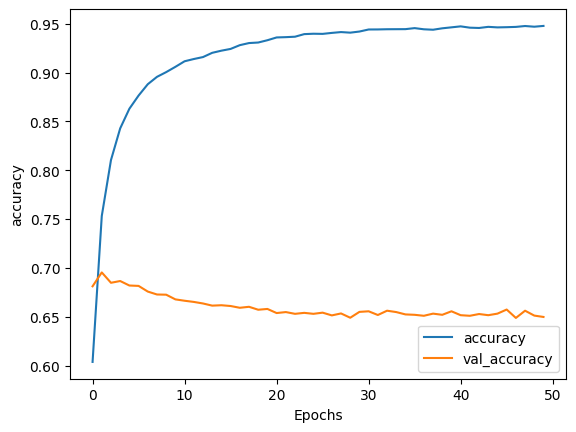

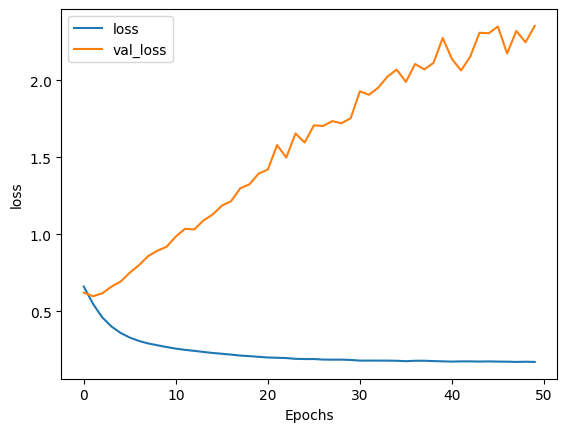

In [100]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")


# Max len + Dropout

In [101]:
tailles = []

for sent in training_sentences:
  tailles.append(len(sent.split(" ")))


In [102]:
np.array(tailles).min(), np.array(tailles).max(), np.array(tailles).mean()


(np.int64(10), np.int64(2470), np.float64(233.90165))

In [103]:
np.median(tailles)


np.float64(174.0)

In [104]:
vocab_size = 29000
embedding_dim=13
maxlen = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(training_sentences)
word_index = tokenizer.word_index

training_sequences = tokenizer.texts_to_sequences(training_sentences)
training_padded = pad_sequences(training_sequences, padding="post", maxlen=maxlen, truncating="post")

test_sequences = tokenizer.texts_to_sequences(test_sentences)
test_padded = pad_sequences(test_sequences, padding="post", maxlen=maxlen, truncating="post")

model = tf.keras.models.Sequential(
    [
        tf.keras.layers.Embedding(vocab_size, embedding_dim),
        tf.keras.layers.GlobalAveragePooling1D(),
        tf.keras.layers.Dense(5, activation='relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(3, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_padded, training_labels, epochs=50,
              validation_data=(test_padded, test_labels),
              callbacks=[model_ckp])


Epoch 1/50
624/625 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5851 - loss: 0.6754

625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.6610 - loss: 0.6384 - val_accuracy: 0.8136 - val_loss: 0.5360
Epoch 2/50
623/625 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8233 - loss: 0.4907

625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8359 - loss: 0.4613 - val_accuracy: 0.8238 - val_loss: 0.4460
Epoch 3/50
622/625 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8901 - loss: 0.3611

625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8894 - loss: 0.3521 - val_accuracy: 0.8368 - val_loss: 0.4132
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9161 - loss: 0.2779 - val_accuracy: 0.8264 - val_loss: 0.4381
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9352 - loss: 0.2275 - val_accuracy: 0.8320 - val_loss: 0.4386
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9437 - loss: 0.1974 - val_accuracy: 0.8326 - val_loss: 0.4678
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.9526 - loss: 0.1711 - val_accuracy: 0.8310 - val_loss: 0.5218
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9572 - loss: 0.1525 - val_accuracy: 0.8288 - val_loss: 0.5479
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9606 - loss: 0.1407 - val_accuracy: 0.8260 - val_loss: 0.5729
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9623 - loss: 0.1326 - val_accuracy: 0.

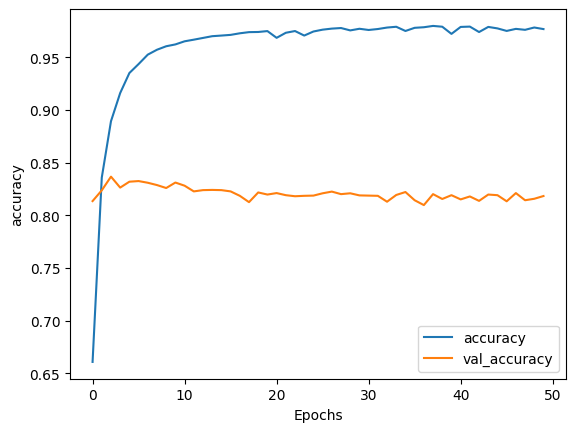

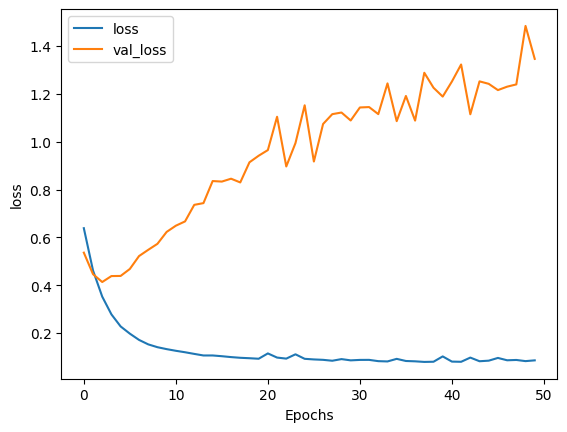

In [105]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")


# Transfert Learning

In [106]:
!pip install --upgrade tensorflow_hub


In [107]:
import tensorflow_hub as hub


c:\Users\utilisateur\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [108]:
embed = hub.load("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1")
embeddings = embed(["cat is on the mat", "dog is in the fog"])


In [109]:
embeddings.shape


TensorShape([2, 20])

In [110]:
train_data, test_data = tfds.load(name="imdb_reviews", split=["train", "test"],
                                  batch_size=-1, as_supervised=True)

train_examples, train_labels = tfds.as_numpy(train_data)
test_examples, test_labels = tfds.as_numpy(test_data)


In [111]:
training_sentences = train_examples[:20000]
training_labels = train_labels[:20000]

test_sentences = train_examples[20000:]
test_labels = train_labels[20000:]


In [112]:
train_labels[20000:]


array([0, 1, 1, ..., 0, 0, 1], shape=(5000,))

In [113]:
train_examples[0]


b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it."

In [114]:
hub_layer = hub.KerasLayer("https://tfhub.dev/google/tf2-preview/gnews-swivel-20dim/1", output_shape=[20],
                           input_shape=[], dtype=tf.string)


In [115]:
model = tf.keras.models.Sequential(
    [
        hub_layer,
        tf.keras.layers.Dense(5, activation='relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(3, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ]
)

model.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])
model_ckp = tf.keras.callbacks.ModelCheckpoint(filepath="best_model.h5",
                            monitor="val_accuracy",
                            mode="max",
                            save_best_only=True)
stop = tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=4, restore_best_weights=True)
h = model.fit(training_sentences, training_labels, epochs=50,
              validation_data=(test_sentences, test_labels),
              callbacks=[model_ckp])


ValueError: Only instances of `keras.Layer` can be added to a Sequential model. Received: <tensorflow_hub.keras_layer.KerasLayer object at 0x000001734B8E4D70> (of type <class 'tensorflow_hub.keras_layer.KerasLayer'>)

In [ ]:
plot_graphs(h, 'accuracy')
plot_graphs(h, "loss")
